# Funk SVD — Collaborative Filtering via Matrix Factorisation

This notebook implements **Funk SVD** from scratch and demonstrates it on:
1. A small toy rating matrix (the Alice/Bob/Carol/Dave example from the lecture)
2. A real e-commerce purchase dataset

**Model.** Decompose the rating matrix $X \approx PQ^\top$ by minimising
$$\min_{P,Q}\ \sum_{(i,j)\in\Omega} \bigl(x_{ij} - p_i^\top q_j\bigr)^2 + \lambda\bigl(\|P\|_F^2 + \|Q\|_F^2\bigr)$$
using SGD over observed entries only.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

rng = np.random.default_rng(42)

## 1. Funk SVD Implementation

In [5]:
class FunkSVD:
    """
    Simon Funk SVD: matrix factorisation X ≈ P Q^T
    trained with SGD on observed entries only.

    Parameters
    ----------
    n_factors : int   — number of latent factors (rank q)
    lr        : float — SGD learning rate η
    reg       : float — L2 regularisation coefficient λ
    n_epochs  : int   — number of passes over the training set
    """

    def __init__(self, n_factors=2, lr=0.01, reg=0.02, n_epochs=100, rng=None):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.rng = rng or np.random.default_rng(0)

    def fit(self, X_obs):
        """
        X_obs : array of shape (n_ratings, 3) with columns [user_id, item_id, rating]
                user_id and item_id should be 0-indexed integers.
        """
        X_obs = np.array(X_obs, dtype=float)
        users = X_obs[:, 0].astype(int)
        items = X_obs[:, 1].astype(int)
        ratings = X_obs[:, 2]

        n_users = users.max() + 1
        n_items = items.max() + 1
        q = self.n_factors

        # Initialise P and Q with small random values
        self.P = self.rng.normal(0, 0.1, (n_users, q))
        self.Q = self.rng.normal(0, 0.1, (n_items, q))

        self.history_ = []

        for epoch in range(self.n_epochs):
            # Shuffle training triplets
            idx = self.rng.permutation(len(ratings))
            epoch_loss = 0.0

            for k in idx:
                i, j, r = users[k], items[k], ratings[k]
                e = r - self.P[i] @ self.Q[j]          # residual
                # SGD updates
                self.P[i] += self.lr * (e * self.Q[j] - self.reg * self.P[i])
                self.Q[j] += self.lr * (e * self.P[i] - self.reg * self.Q[j])
                epoch_loss += e ** 2 + self.reg * (np.sum(self.P[i]**2) + np.sum(self.Q[j]**2))

            self.history_.append(epoch_loss / len(ratings))

        return self

    def predict(self, user_id, item_id):
        return self.P[user_id] @ self.Q[item_id]

    def predict_matrix(self):
        """Return the full predicted rating matrix P Q^T."""
        return self.P @ self.Q.T

## 2. Toy Example — Movies

The rating matrix from the lecture (NaN = not rated, 1–5 stars):

|          | Inception | Titanic | Alien | La La Land | Interstellar |
|----------|:---------:|:-------:|:-----:|:----------:|:------------:|
| Alice    | 5         | 3       | 4     | 2          | **?**        |
| Bob      | 4         | 1       | 5     | 1          | 5            |
| Carol    | **?**     | 5       | 1     | **?**      | 2            |
| Dave     | **?**     | 4       | 2     | 5          | 3            |

In [6]:
users  = ['Alice', 'Bob', 'Carol', 'Dave']
movies = ['Inception', 'Titanic', 'Alien', 'La La Land', 'Interstellar']

# Full matrix (NaN = unobserved)
X_full = np.array([
    [5,   3,   4,   2,   np.nan],   # Alice
    [4,   1,   5,   1,   5     ],   # Bob
    [np.nan, 5, 1, np.nan, 2   ],   # Carol
    [np.nan, 4, 2,  5,    3    ],   # Dave
])

# Build training triplets [user_id, item_id, rating] for observed entries
obs = [(i, j, X_full[i, j])
       for i in range(X_full.shape[0])
       for j in range(X_full.shape[1])
       if not np.isnan(X_full[i, j])]

print(f"Observed ratings: {len(obs)}")
print(f"Total entries:    {X_full.size}")
print(f"Density:          {len(obs)/X_full.size:.0%}")

Observed ratings: 16
Total entries:    20
Density:          80%


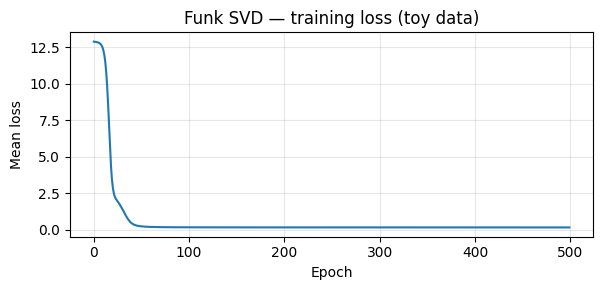

In [7]:
model_toy = FunkSVD(n_factors=2, lr=0.02, reg=0.01, n_epochs=500, rng=rng)
model_toy.fit(obs)

# ---- Convergence plot ----
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(model_toy.history_)
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean loss')
ax.set_title('Funk SVD — training loss (toy data)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
X_pred = model_toy.predict_matrix()

# Show predicted matrix next to the known values
df_true = pd.DataFrame(X_full, index=users, columns=movies)
df_pred = pd.DataFrame(X_pred.round(2), index=users, columns=movies)

print("=== True ratings (NaN = unobserved) ===")
print(df_true.to_string())
print()
print("=== Predicted ratings ===")
print(df_pred.to_string())

=== True ratings (NaN = unobserved) ===
       Inception  Titanic  Alien  La La Land  Interstellar
Alice        5.0      3.0    4.0         2.0           NaN
Bob          4.0      1.0    5.0         1.0           5.0
Carol        NaN      5.0    1.0         NaN           2.0
Dave         NaN      4.0    2.0         5.0           3.0

=== Predicted ratings ===
       Inception  Titanic  Alien  La La Land  Interstellar
Alice       4.93     2.53   4.07        2.39          4.49
Bob         4.04     1.28   4.89        0.72          4.99
Carol       5.84     4.94   0.95        5.89          2.06
Dave        5.63     4.20   2.04        4.79          2.93


In [9]:
# Highlight the missing predictions
missing = [(i, j) for i in range(X_full.shape[0])
                   for j in range(X_full.shape[1])
                   if np.isnan(X_full[i, j])]

print("Predictions for unobserved entries:")
print(f"  {'User':<8} {'Movie':<14} {'Predicted':>10}")
print("  " + "-"*34)
for i, j in missing:
    print(f"  {users[i]:<8} {movies[j]:<14} {X_pred[i, j]:>10.2f}")

Predictions for unobserved entries:
  User     Movie           Predicted
  ----------------------------------
  Alice    Interstellar         4.49
  Carol    Inception            5.84
  Carol    La La Land           5.89
  Dave     Inception            5.63


## 3. Visualising Latent Factors

With `n_factors=2` we can plot users and items in the same 2-D latent space.
Users and items that are close tend to be compatible (high predicted rating).

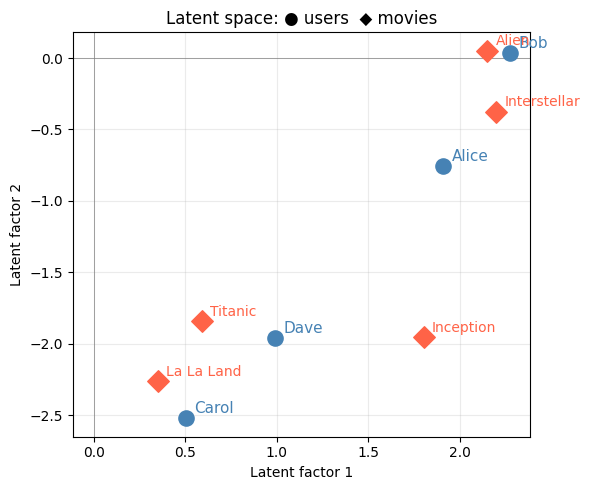

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

# Plot users (P vectors)
for i, name in enumerate(users):
    ax.scatter(*model_toy.P[i], s=120, color='steelblue', zorder=3)
    ax.annotate(name, model_toy.P[i], textcoords='offset points',
                xytext=(6, 4), color='steelblue', fontsize=11)

# Plot movies (Q vectors)
for j, name in enumerate(movies):
    ax.scatter(*model_toy.Q[j], s=120, marker='D', color='tomato', zorder=3)
    ax.annotate(name, model_toy.Q[j], textcoords='offset points',
                xytext=(6, 4), color='tomato', fontsize=10)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Latent factor 1')
ax.set_ylabel('Latent factor 2')
ax.set_title('Latent space: ● users  ◆ movies')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Effect of Rank `q` and Regularisation `λ`

On toy data we can measure **RMSE on observed entries** (we don't have a hold-out set).
Watch how training RMSE changes with `n_factors` and `reg`.

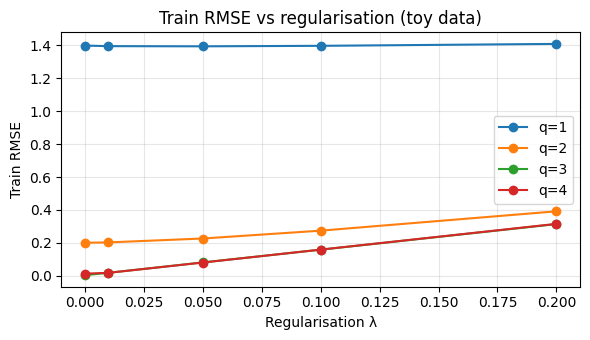

q          1       2       3       4
λ                                   
0.00  1.3988  0.2006  0.0037  0.0129
0.01  1.3953  0.2028  0.0181  0.0178
0.05  1.3942  0.2264  0.0811  0.0803
0.10  1.3973  0.2741  0.1585  0.1588
0.20  1.4090  0.3917  0.3139  0.3155


In [11]:
def rmse_on_obs(model, obs):
    errors = [(r - model.predict(int(i), int(j)))**2 for i, j, r in obs]
    return np.sqrt(np.mean(errors))

factors_grid = [1, 2, 3, 4]
reg_grid     = [0.0, 0.01, 0.05, 0.1, 0.2]

results = []
for q in factors_grid:
    for lam in reg_grid:
        m = FunkSVD(n_factors=q, lr=0.02, reg=lam, n_epochs=500,
                    rng=np.random.default_rng(0))
        m.fit(obs)
        results.append({'q': q, 'λ': lam, 'RMSE': rmse_on_obs(m, obs)})

df_res = pd.DataFrame(results).pivot(index='λ', columns='q', values='RMSE')

fig, ax = plt.subplots(figsize=(6, 3.5))
for q in factors_grid:
    ax.plot(df_res.index, df_res[q], marker='o', label=f'q={q}')
ax.set_xlabel('Regularisation λ')
ax.set_ylabel('Train RMSE')
ax.set_title('Train RMSE vs regularisation (toy data)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(df_res.round(4))

## 5. Real Data — E-commerce Purchases

We use `purchase` events from the clickstream dataset.  
**Rating proxy**: total amount spent by user $i$ on product $j$ (log-scaled).  
We keep only users and products with at least 2 purchases to get a denser matrix.

In [12]:
df_raw = pd.read_csv('datasets/ecommerce_clickstream_transactions.csv')
df_buy = df_raw[df_raw['EventType'] == 'purchase'].copy()
df_buy['Amount'] = pd.to_numeric(df_buy['Amount'], errors='coerce')
df_buy = df_buy.dropna(subset=['Amount', 'ProductID'])

# Aggregate: sum of amount per (user, product)
df_agg = (df_buy.groupby(['UserID', 'ProductID'])['Amount']
                .sum()
                .reset_index()
                .rename(columns={'Amount': 'rating'}))

# Log-scale the rating to compress the range
df_agg['rating'] = np.log1p(df_agg['rating'])

# Filter to users/products with at least 2 entries for a denser matrix
min_count = 2
user_counts = df_agg['UserID'].value_counts()
prod_counts = df_agg['ProductID'].value_counts()
df_agg = df_agg[
    df_agg['UserID'].isin(user_counts[user_counts >= min_count].index) &
    df_agg['ProductID'].isin(prod_counts[prod_counts >= min_count].index)
]

# Re-index to 0-based integers
user_enc  = {u: i for i, u in enumerate(df_agg['UserID'].unique())}
prod_enc  = {p: j for j, p in enumerate(df_agg['ProductID'].unique())}
df_agg['uid'] = df_agg['UserID'].map(user_enc)
df_agg['pid'] = df_agg['ProductID'].map(prod_enc)

n_users = df_agg['uid'].nunique()
n_prods = df_agg['pid'].nunique()
density = len(df_agg) / (n_users * n_prods)

print(f"Users:    {n_users}")
print(f"Products: {n_prods}")
print(f"Ratings:  {len(df_agg)}")
print(f"Density:  {density:.3%}")

Users:    1000
Products: 2982
Ratings:  7401
Density:  0.248%


In [13]:
# Train / test split: hold out 20 % of entries randomly
mask = rng.random(len(df_agg)) < 0.8
train_df = df_agg[mask]
test_df  = df_agg[~mask]

train_obs = train_df[['uid', 'pid', 'rating']].values
test_obs  = test_df [['uid', 'pid', 'rating']].values

print(f"Train: {len(train_obs)}   Test: {len(test_obs)}")

Train: 5971   Test: 1430


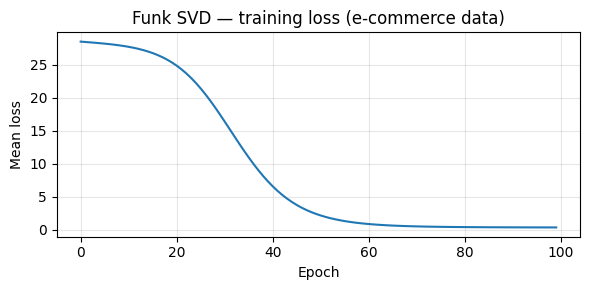

In [14]:
model_real = FunkSVD(n_factors=10, lr=0.005, reg=0.02, n_epochs=100, rng=rng)
model_real.fit(train_obs)

# ---- Convergence ----
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(model_real.history_)
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean loss')
ax.set_title('Funk SVD — training loss (e-commerce data)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
def evaluate(model, obs_array):
    preds = np.array([model.predict(int(i), int(j)) for i, j, _ in obs_array])
    truth = obs_array[:, 2]
    rmse  = np.sqrt(np.mean((truth - preds)**2))
    mae   = np.mean(np.abs(truth - preds))
    return rmse, mae

train_rmse, train_mae = evaluate(model_real, train_obs)
test_rmse,  test_mae  = evaluate(model_real, test_obs)

print(f"{'':12} {'RMSE':>8} {'MAE':>8}")
print(f"{'Train':12} {train_rmse:>8.4f} {train_mae:>8.4f}")
print(f"{'Test':12} {test_rmse:>8.4f} {test_mae:>8.4f}")

                 RMSE      MAE
Train          0.1180   0.0773
Test           5.6274   5.2720


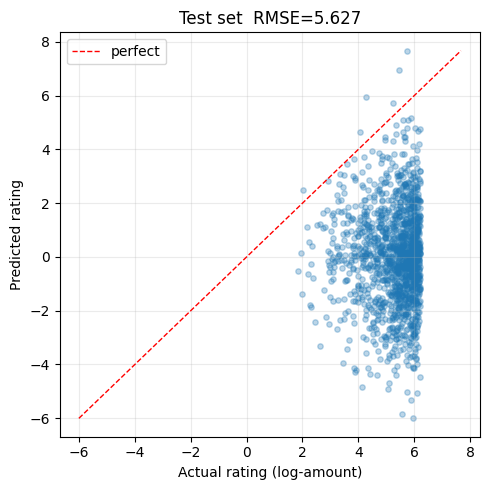

In [16]:
# ---- Predicted vs actual (test set) ----
preds = np.array([model_real.predict(int(i), int(j)) for i, j, _ in test_obs])
truth = test_obs[:, 2]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(truth, preds, alpha=0.3, s=15)
lo, hi = min(truth.min(), preds.min()), max(truth.max(), preds.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='perfect')
ax.set_xlabel('Actual rating (log-amount)')
ax.set_ylabel('Predicted rating')
ax.set_title(f'Test set  RMSE={test_rmse:.3f}')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Top-N Recommendations for a Sample User

In [17]:
sample_uid = 0   # first user in our encoded space
original_user = [u for u, i in user_enc.items() if i == sample_uid][0]

# Products already purchased by this user (in training set)
already_bought = set(train_df[train_df['uid'] == sample_uid]['pid'])

# Score all products and rank them
all_pids  = np.arange(n_prods)
all_preds = model_real.P[sample_uid] @ model_real.Q.T

# Mask already-bought items
unseen_mask  = np.array([p not in already_bought for p in all_pids])
ranked_pids  = all_pids[unseen_mask][np.argsort(-all_preds[unseen_mask])]

# Reverse-encode
pid_to_prod = {v: k for k, v in prod_enc.items()}

print(f"Top-10 recommendations for user {original_user}:")
for rank, pid in enumerate(ranked_pids[:10], 1):
    print(f"  {rank:2d}. {pid_to_prod[pid]}   (score={all_preds[pid]:.3f})")

Top-10 recommendations for user 1:
   1. prod_4566   (score=5.432)
   2. prod_2960   (score=5.132)
   3. prod_7171   (score=5.019)
   4. prod_2985   (score=4.978)
   5. prod_4857   (score=4.802)
   6. prod_3001   (score=4.685)
   7. prod_7720   (score=4.667)
   8. prod_7504   (score=4.617)
   9. prod_8096   (score=4.541)
  10. prod_8671   (score=4.508)
